In [1]:
import json
import os

DATA_DIR = "data"
with open(os.path.join(DATA_DIR, "turtle-data", "annotations.json"), "r") as f:
    annotations = json.load(f)

categories = [{'id': c['id'], 'name': c['name']} for c in annotations['categories']]

sample_idx = 0
sample_img = annotations["images"][sample_idx]
sample_annotation = annotations["annotations"][sample_idx]

print(f"""
    =====================================================
    SeaTurtleID2022 Dataset Annotations JSON Contents:
    =====================================================

    > Sample Image Data (index: {sample_idx}): 
        {sample_img}

    > Sample Annotation Data (index: {sample_idx}): 
        {sample_annotation}

    =====================================================
""")


    SeaTurtleID2022 Dataset Annotations JSON Contents:

    > Sample Image Data (index: 0): 
        {'id': 1, 'width': 2000, 'height': 1333, 'file_name': 'images/t001/CAluWEgwPX.JPG', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0, 'timestamp': '2014:07:14 14:49:45', 'identity': 't001'}

    > Sample Annotation Data (index: 0): 
        {'id': 1, 'image_id': 1, 'category_id': 3, 'segmentation': {'counts': [858927, 7, 1322, 23, 1306, 34, 1298, 36, 1296, 39, 1292, 42, 1291, 43, 1289, 45, 1287, 47, 1285, 48, 1285, 49, 1283, 51, 1281, 53, 1280, 54, 1278, 56, 1277, 56, 1277, 57, 1275, 58, 1274, 60, 1273, 61, 1272, 61, 1272, 62, 1270, 63, 1269, 64, 1268, 65, 1268, 65, 1268, 66, 1267, 67, 1266, 67, 1265, 68, 1264, 69, 1263, 70, 1263, 70, 1263, 70, 1263, 70, 1263, 70, 1263, 70, 1262, 71, 1261, 72, 1261, 72, 1261, 72, 1261, 72, 1261, 72, 1261, 72, 1261, 72, 1260, 73, 1260, 73, 1260, 73, 1259, 74, 1258, 75, 1258, 74, 1259, 73, 1260, 72, 1261, 71, 1262, 69, 1263, 69, 1264, 6

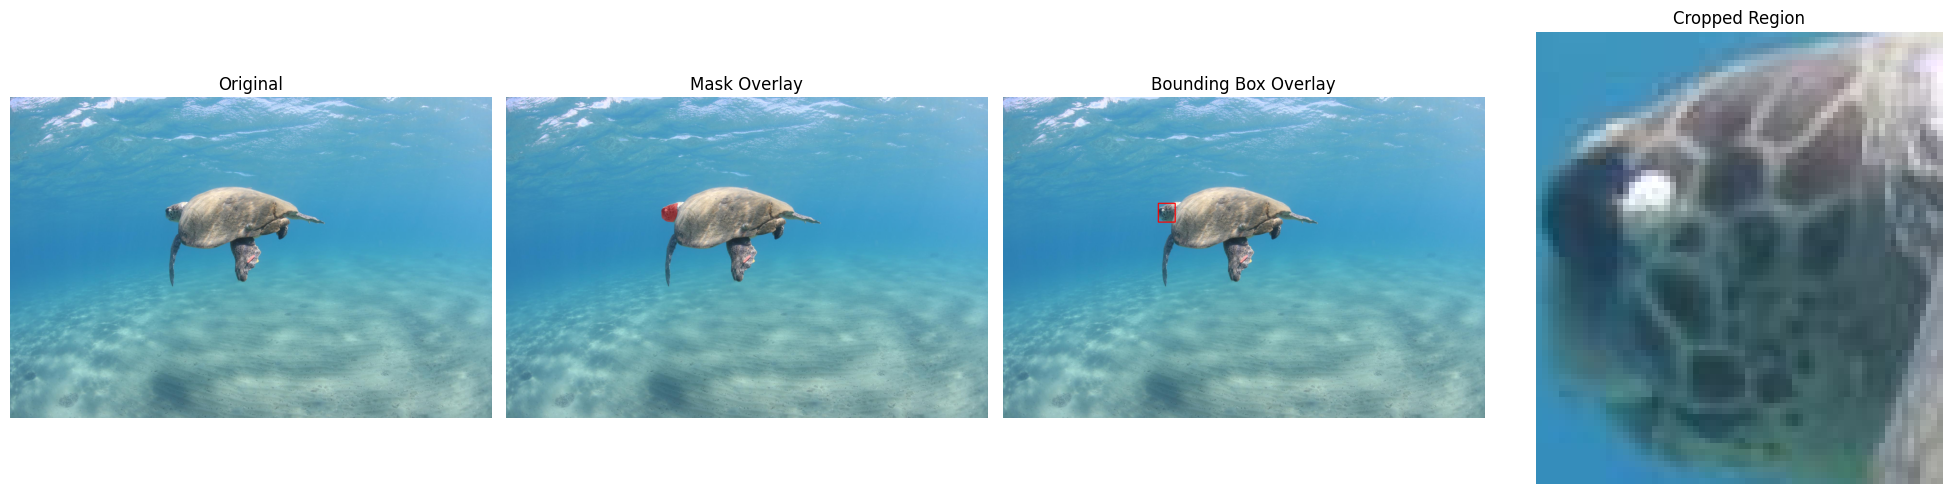

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools import mask as maskUtils

# 1. Build full image path
img_rel_path = sample_img["file_name"]  # e.g. 'images/t001/CAluWEgwPX.JPG'
img_path = os.path.join(DATA_DIR, "turtle-data", img_rel_path)

# 2. Load image with OpenCV and convert to RGB for matplotlib
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image at: {img_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Decode RLE segmentation into a binary mask
rle = sample_annotation["segmentation"]

if isinstance(rle["counts"], list):  # convert FRLE -> RLE
    rle = maskUtils.frPyObjects(rle, rle["size"][0], rle["size"][1])

mask = maskUtils.decode(rle)
if mask.ndim == 3:
    mask = mask[:, :, 0]

mask_bool = mask.astype(bool)

# 4. Create red mask overlay
overlay = img_rgb.copy()
overlay[mask_bool] = [255, 0, 0]
alpha = 0.4
blended = (alpha * overlay + (1 - alpha) * img_rgb).astype(np.uint8)

# 5. Create bounding box overlay
bbox = sample_annotation["bbox"]  # [x, y, w, h]
x, y, w, h = bbox
x1, y1 = int(x), int(y)
x2, y2 = int(x + w), int(y + h)

img_bbox = img_rgb.copy()
cv2.rectangle(img_bbox, (x1, y1), (x2, y2), (255, 0, 0), 3)

# --- Create crop from bbox (non-destructive) ---
x, y, w, h = sample_annotation["bbox"]
x, y, w, h = int(x), int(y), int(w), int(h)

cropped_img = img_rgb[y:y+h, x:x+w].copy()   # .copy() ensures no link to original

# 6. Display all three images plus the cropped image
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(blended)
plt.title("Mask Overlay")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_bbox)
plt.title("Bounding Box Overlay")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cropped_img)
plt.title("Cropped Region")
plt.axis("off")

plt.tight_layout()
plt.show()
